# Showin GAF images

## Function for process data

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
from pyts.image import GramianAngularField

def process_data(data_name, sample_number, im_size):
    base_path = Path(f"D:/AIoT_project/data_sets/IEEE_dataPort/AES-{data_name}_power_Temp25C/AES-{data_name}_power_Temp25C")
    trj_disabled = Path(f"AES-{data_name}+TrojanDisabled_1/AES-{data_name}+TrojanDisabled_1")
    trj_enabled = Path(f"AES-{data_name}+TrojanTriggered_1/AES-{data_name}+TrojanTriggered_1")

    # Trojan Disabled Data
    data_folder = base_path / trj_disabled
    file_path = data_folder / f"Sample_{sample_number}.csv"
    data = pd.read_csv(file_path, header=None)
    trj_data_disb = np.array([data[0].to_numpy()])

    # Trojan Enabled Data
    data_folder = base_path / trj_enabled
    file_path = data_folder / f"Sample_{sample_number}.csv"
    data = pd.read_csv(file_path, header=None)
    trj_data_trig = np.array([data[0].to_numpy()])
    # Concatenate and Reshape
    trj_data = np.concatenate((trj_data_disb, trj_data_trig), axis=0)
    X = trj_data.reshape(-1, 1, 50, 50)
    # Normalize
    mean = X.mean()
    std = X.std()
    X_cnn= (X - mean) / std

    # Gramian Angular Field Transformation
    tf_gs = GramianAngularField(image_size=im_size, method='s')
    X_gs = tf_gs.fit_transform(trj_data)
    X_gs = X_gs.reshape(-1, 1, im_size, im_size)
    X_end = np.concatenate((X_cnn, X_gs), axis=0)

    return X_end


(4, 1, 50, 50)
(50, 50)


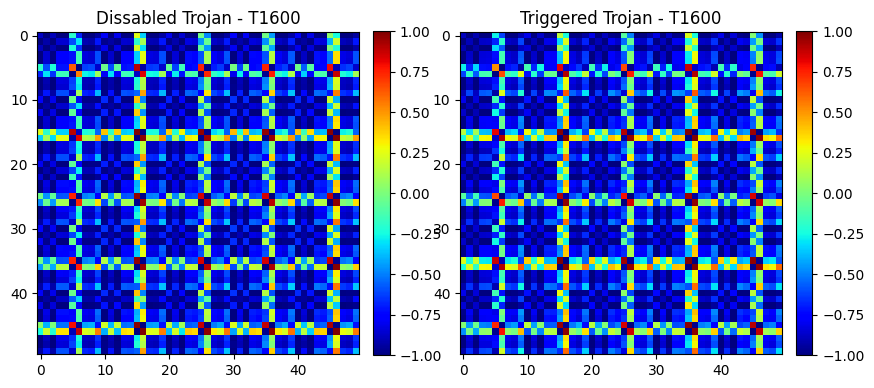

In [2]:
import matplotlib.pyplot as plt
import numpy as np
data_name = "T1600"
sample_number = 1  # Example sample number
im_size = 50  # Image size for GAF transformation

X=process_data(data_name, sample_number, im_size)
# Example matrices
print(X.shape)
matrix1 = X[2,0,:,:]
matrix2 = X[3,0,:,:]
print(matrix1.shape)
# Create a figure and a set of subplots
fig, ax = plt.subplots(1, 2, figsize=(10, 5))  # 1 row, 2 columns

# Display matrix1 in the first subplot
cax1 = ax[1].imshow(matrix1, cmap='jet', interpolation='nearest')
ax[1].title.set_text(f'Triggered Trojan - {data_name}')
fig.colorbar(cax1, ax=ax[1], fraction=0.046, pad=0.04)

# Display matrix2 in the second subplot
cax2 = ax[0].imshow(matrix2, cmap='jet', interpolation='nearest')
ax[0].title.set_text(f'Dissabled Trojan - {data_name}')
fig.colorbar(cax1, ax=ax[0], fraction=0.046, pad=0.04)

plt.show()

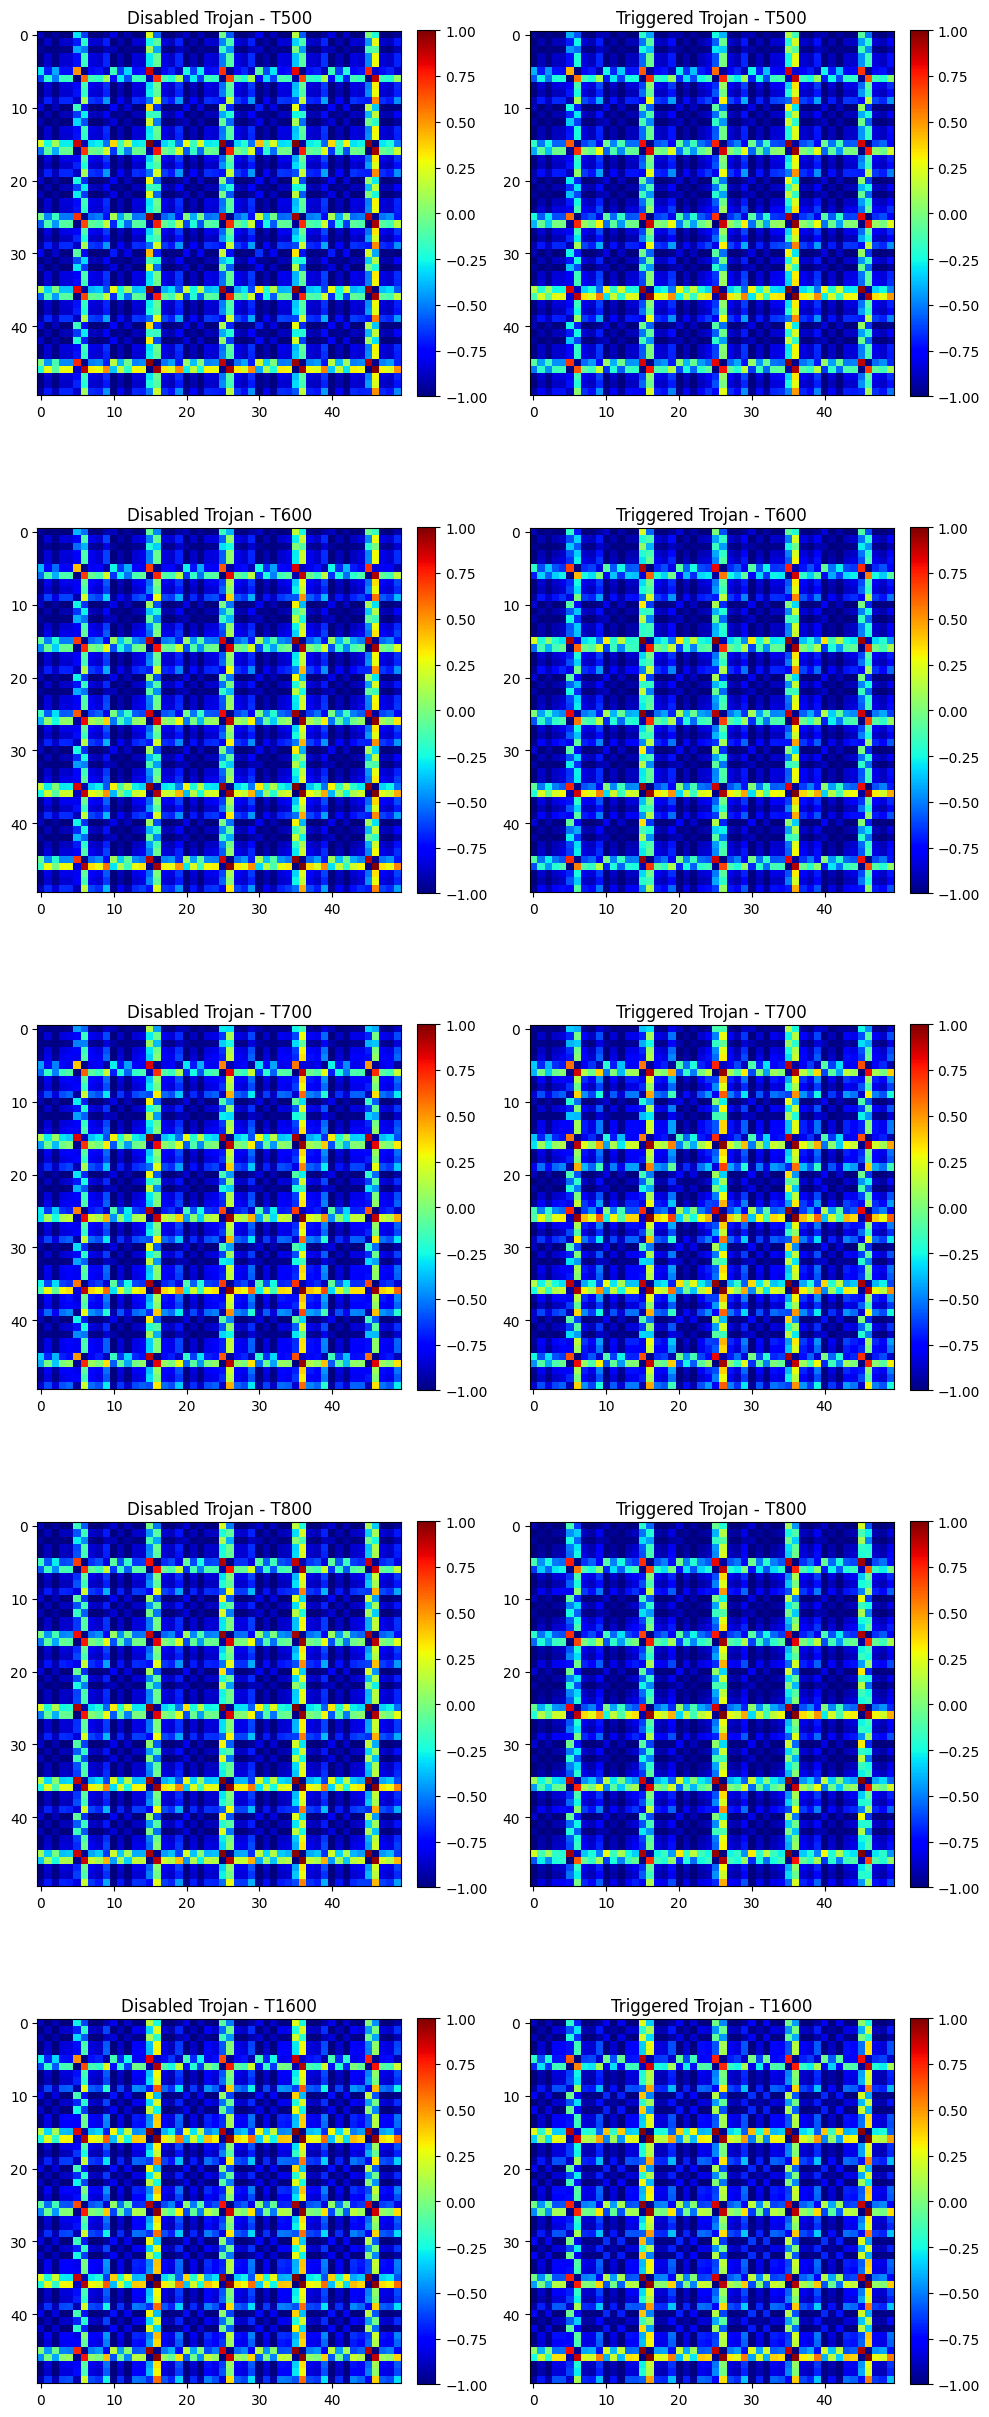

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming process_data is a function that returns the data as previously defined

data_names = ["T500", "T600", "T700", "T800", "T1600"]
sample_number = 1  # Example sample number
im_size = 50  # Image size for GAF transformation

# Create a figure and a set of subplots
fig, axs = plt.subplots(5, 2, figsize=(10, 25))  # 5 rows, 2 columns

for i, data_name in enumerate(data_names):
    X = process_data(data_name, sample_number, im_size)
    # Assuming X is returned correctly by process_data and has the expected shape
    # Select two matrices for demonstration
    matrix1 = X[2, 0, :, :]
    matrix2 = X[3, 0, :, :]
    
    # Display matrix1 in the first column for the current row
    cax1 = axs[i, 0].imshow(matrix1, cmap='jet', interpolation='nearest')
    axs[i, 0].title.set_text(f'Disabled Trojan - {data_name}')
    fig.colorbar(cax1, ax=axs[i, 0], fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed
    
    # Display matrix2 in the second column for the current row
    cax2 = axs[i, 1].imshow(matrix2, cmap='jet', interpolation='nearest')
    axs[i, 1].title.set_text(f'Triggered Trojan - {data_name}')
    fig.colorbar(cax2, ax=axs[i, 1], fraction=0.046, pad=0.04)  # Adjust fraction and pad as needed

plt.tight_layout()
plt.show()


## Convert to PyTorch tensors

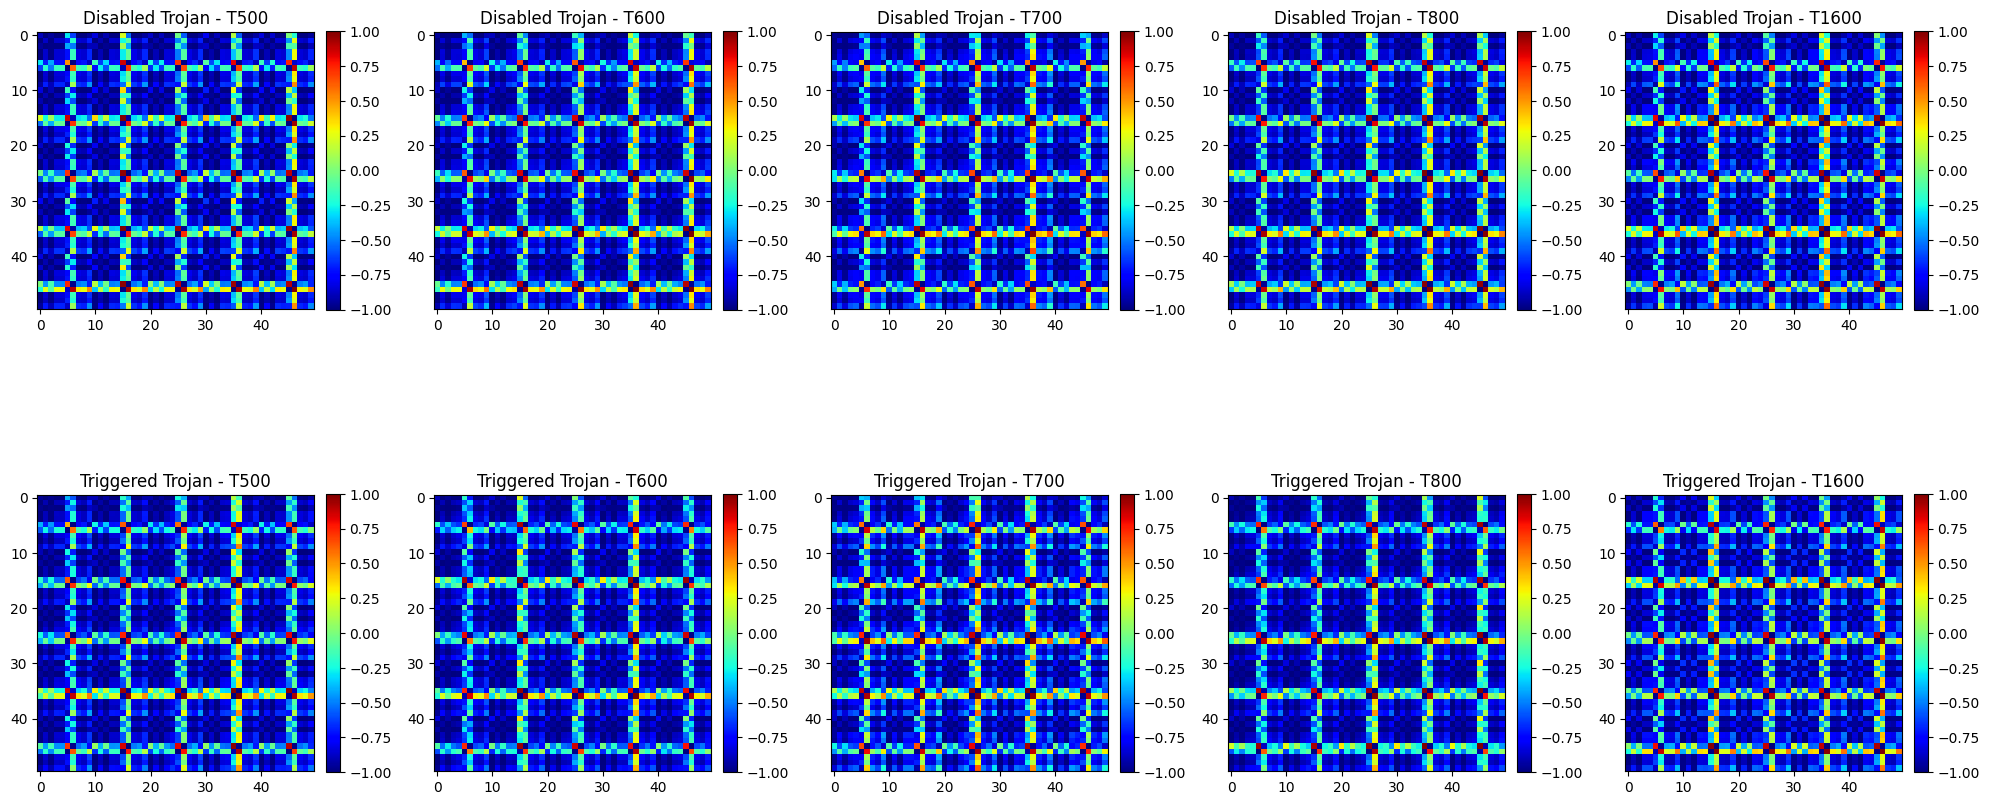

In [5]:
import matplotlib.pyplot as plt
import numpy as np

# Assuming process_data is defined as before

data_names = ["T500", "T600", "T700", "T800", "T1600"]
sample_number = 1  # Example sample number
im_size = 50  # Image size for GAF transformation

# Create a figure and a set of subplots arranged in 2 rows and 5 columns
fig, axs = plt.subplots(2, 5, figsize=(20, 10))  # 2 rows, 5 columns

for i, data_name in enumerate(data_names):
    X = process_data(data_name, sample_number, im_size)
    matrix1 = X[2, 0, :, :]
    matrix2 = X[3, 0, :, :]
    
    # The first row will contain the Disabled Trojan figures
    cax1 = axs[0, i].imshow(matrix1, cmap='jet', interpolation='nearest')
    axs[0, i].title.set_text(f'Disabled Trojan - {data_name}')
    fig.colorbar(cax1, ax=axs[0, i], fraction=0.046, pad=0.04)
    
    # The second row will contain the Triggered Trojan figures
    cax2 = axs[1, i].imshow(matrix2, cmap='jet', interpolation='nearest')
    axs[1, i].title.set_text(f'Triggered Trojan - {data_name}')
    fig.colorbar(cax2, ax=axs[1, i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


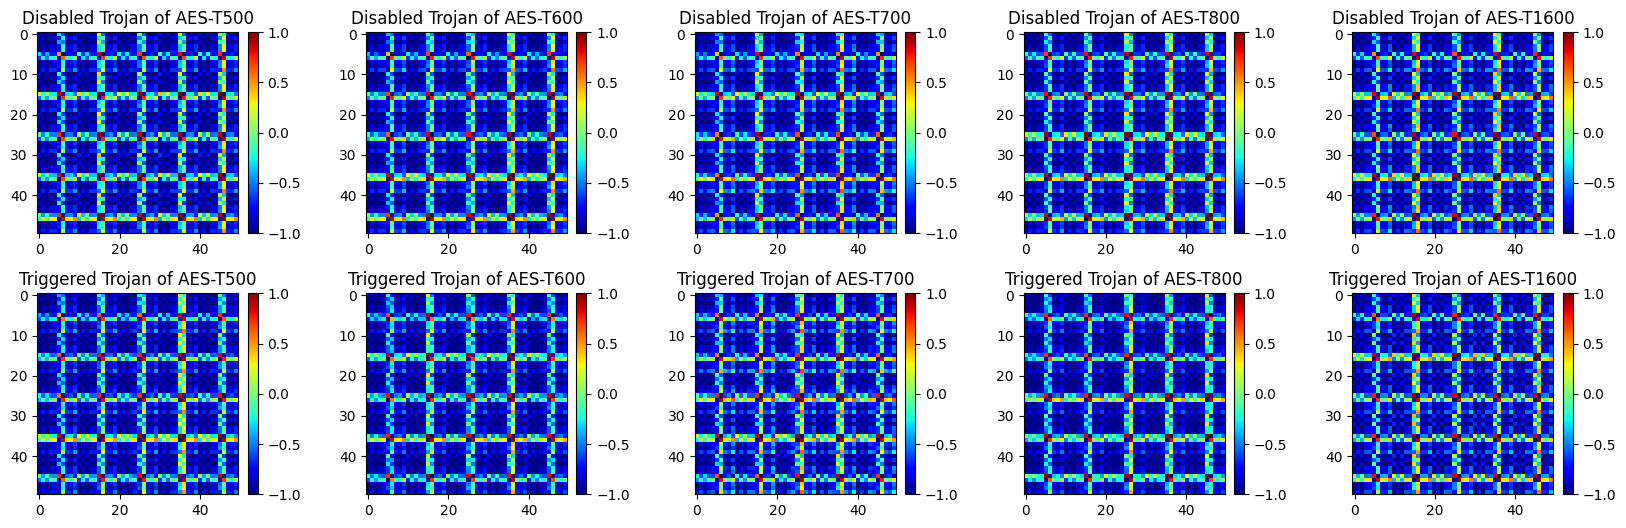

In [8]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

# Assuming process_data function is defined and working as expected

data_names = ["T500", "T600", "T700", "T800", "T1600"]

sample_number = 1
im_size = 50

# Initialize figure and GridSpec with 2 rows and 5 columns
fig = plt.figure(figsize=(20, 6))
gs = gridspec.GridSpec(2, 5, figure=fig, height_ratios=[1, 1], hspace=0.3, wspace=0.4)

for i, data_name in enumerate(data_names):
    X = process_data(data_name, sample_number, im_size)
    
    # Assume X is structured correctly for extraction
    matrix1 = X[2, 0, :, :]
    matrix2 = X[3, 0, :, :]

    # First row for Disabled Trojan
    ax1 = fig.add_subplot(gs[0, i])
    cax1 = ax1.imshow(matrix1, cmap='jet', interpolation='nearest')
    ax1.title.set_text(f'Disabled Trojan of AES-{data_name}')
    plt.colorbar(cax1, ax=ax1, fraction=0.046, pad=0.04)
    
    # Second row for Triggered Trojan
    ax2 = fig.add_subplot(gs[1, i])
    cax2 = ax2.imshow(matrix2, cmap='jet', interpolation='nearest')
    ax2.title.set_text(f'Triggered Trojan of AES-{data_name}')
    plt.colorbar(cax2, ax=ax2, fraction=0.046, pad=0.04)

plt.show()
